# Telco Customer Churn — End-to-End ML Pipeline

**AAI-540 Group Project**

This notebook runs the complete pipeline end-to-end: data preprocessing,
feature engineering, model training & selection, and a fairness audit.
It mirrors the production code in `src/preprocess.py`, `src/features.py`,
`src/train.py`, and `src/fairness_audit.py` — the same functions are
imported directly from those modules so this notebook and the production
pipeline can never silently drift apart.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
(Kaggle / IBM sample data), 7,043 customers × 21 columns.

## 0. Setup

In [1]:
import sys
sys.path.insert(0, "../src")
sys.path.insert(0, "../monitoring")

import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from preprocess import load_raw, clean, add_derived_features, run_pipeline
from features import build_preprocessing_pipeline, get_feature_target_split, FEATURE_COLS
from train import (
    make_splits, evaluate, train_logistic_regression,
    train_random_forest, train_xgboost, get_feature_importance, RANDOM_STATE,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Load Raw Data

In [2]:
raw_df = load_raw("../data/raw/telco_churn.csv")
print(f"Shape: {raw_df.shape}")
raw_df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.1 Initial data quality checks

Before cleaning, we confirm the specific data issues the design document
calls out: blank `TotalCharges` values, duplicate rows, and the overall
class balance of the target.

In [3]:
print("Duplicate rows:", raw_df.duplicated().sum())
print("Blank TotalCharges rows:", (raw_df["TotalCharges"].astype(str).str.strip() == "").sum())
print()
print("Churn distribution:")
print(raw_df["Churn"].value_counts())
print(raw_df["Churn"].value_counts(normalize=True).round(4))

Duplicate rows: 0
Blank TotalCharges rows: 11

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


## 2. Data Cleaning & Preprocessing

`clean()` performs four steps, in order:
1. Coerce `TotalCharges` to numeric, imputing blanks (zero-tenure customers) as 0.0
2. Drop `customerID` (non-predictive identifier)
3. Drop exact-duplicate rows defensively
4. Binary-encode `gender` and all Yes/No columns to 0/1

In [4]:
cleaned_df = clean(raw_df)
print(f"Rows after cleaning: {len(cleaned_df)} (was {len(raw_df)})")
print(f"Missing TotalCharges values imputed: {cleaned_df.attrs.get('n_missing_total_charges_imputed', 0)}")
cleaned_df.head()

Rows after cleaning: 7021 (was 7043)
Missing TotalCharges values imputed: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## 3. Exploratory Data Analysis

With the data cleaned and binary-encoded, we look at the relationships
between key features and churn before engineering derived features.

### 3.1 Churn rate by contract type
Contract length is expected to be the strongest categorical predictor.

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


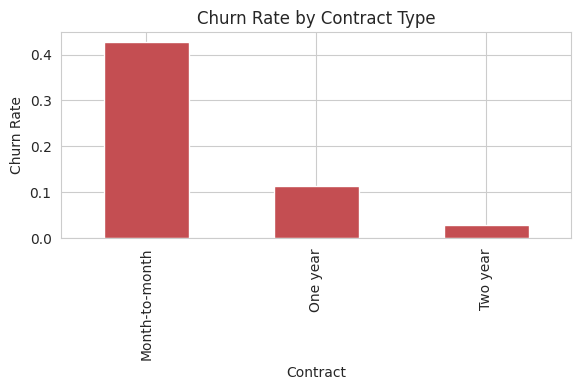

In [5]:
contract_raw = raw_df.copy()
contract_raw["Churn"] = contract_raw["Churn"].map({"Yes": 1, "No": 0})
churn_by_contract = contract_raw.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
print(churn_by_contract)

fig, ax = plt.subplots(figsize=(6, 4))
churn_by_contract.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()

### 3.2 Churn rate by payment method

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64


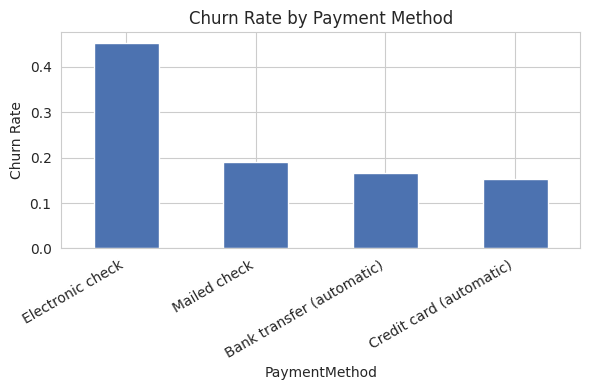

In [6]:
churn_by_payment = contract_raw.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)
print(churn_by_payment)

fig, ax = plt.subplots(figsize=(6, 4))
churn_by_payment.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Churn Rate by Payment Method")
ax.set_ylabel("Churn Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 3.3 Tenure and Monthly Charges distributions by churn status

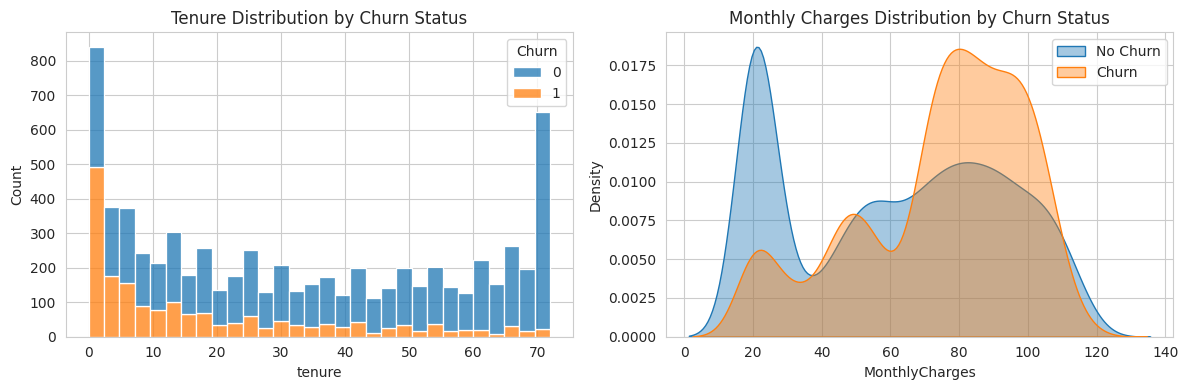

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=cleaned_df, x="tenure", hue="Churn", multiple="stack", bins=30, ax=axes[0])
axes[0].set_title("Tenure Distribution by Churn Status")

sns.kdeplot(data=cleaned_df[cleaned_df["Churn"] == 0], x="MonthlyCharges", label="No Churn", fill=True, alpha=0.4, ax=axes[1])
sns.kdeplot(data=cleaned_df[cleaned_df["Churn"] == 1], x="MonthlyCharges", label="Churn", fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title("Monthly Charges Distribution by Churn Status")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Correlation among numeric features

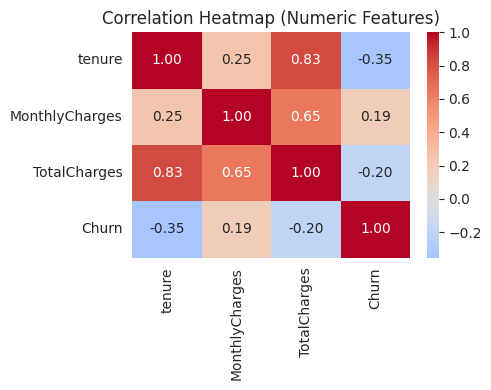

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr = cleaned_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

`add_derived_features()` adds three engineered columns on top of the
cleaned data:
- `tenure_group`: bucketed lifecycle stage (0–12, 13–24, 25–48, 49–72 months)
- `has_support_services`: binary flag for OnlineSecurity OR TechSupport
- `num_services`: count of subscribed add-on services (0–8)

In [9]:
featured_df = add_derived_features(cleaned_df)
featured_df[["tenure", "tenure_group", "has_support_services", "num_services", "Churn"]].head(10)

,tenure,tenure_group,has_support_services,num_services,Churn
0,1,0-12,0,2,0
1,34,25-48,1,4,0
2,2,0-12,1,4,1
3,45,25-48,1,4,0
4,2,0-12,0,2,1
5,8,0-12,0,6,1
6,22,13-24,0,5,0
7,10,0-12,1,2,0
8,28,25-48,1,7,1
9,62,49-72,1,4,0


### 4.1 Validating the derived features against churn

Each derived feature is checked against the actual churn rate to confirm
it carries real separating signal before it's trusted downstream.

In [10]:
print("Churn rate by tenure_group:")
print(featured_df.groupby("tenure_group")["Churn"].mean())
print()
print("Churn rate by has_support_services:")
print(featured_df.groupby("has_support_services")["Churn"].mean())
print()
print("num_services distribution:")
print(featured_df["num_services"].describe())

Churn rate by tenure_group:
tenure_group
0-12     0.473660
13-24    0.287109
25-48    0.203890
49-72    0.095132
Name: Churn, dtype: float64

Churn rate by has_support_services:
has_support_services
0    0.333005
1    0.170715
Name: Churn, dtype: float64

num_services distribution:
count    7021.000000
mean        4.154964
std         2.310924
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: num_services, dtype: float64


## 5. Build the Preprocessing Pipeline

`build_preprocessing_pipeline()` returns a `ColumnTransformer` with three
branches: binary passthrough, one-hot encoding (`handle_unknown="ignore"`)
for multi-category columns, and `StandardScaler` for continuous columns.
This transformer is fit only on the training split — never on
validation/test — to avoid leakage.

In [11]:
X, y = get_feature_target_split(featured_df)
print("Feature columns:", FEATURE_COLS)
print("X shape:", X.shape, " y shape:", y.shape)

Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'has_support_services', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_group', 'tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']
X shape: (7021, 22)  y shape: (7021,)


## 6. Train / Validation / Test Split

Stratified 70/15/15 split, preserving the ~26.5% churn rate across all
three partitions.

In [12]:
X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X, y)

print(f"Train: {len(X_train)}   Val: {len(X_val)}   Test: {len(X_test)}")
print(f"Train churn rate: {y_train.mean():.4f}")
print(f"Val churn rate:   {y_val.mean():.4f}")
print(f"Test churn rate:  {y_test.mean():.4f}")

Train: 4914   Val: 1053   Test: 1054
Train churn rate: 0.2646
Val churn rate:   0.2640
Test churn rate:  0.2647


## 7. Model Training & Comparison

Three candidates are trained under identical conditions and compared on
the validation set by AUC-ROC:
- **Logistic Regression** — `class_weight="balanced"`, L2 regularization
- **Random Forest** — GridSearchCV-tuned, trained on SMOTE-resampled data
- **XGBoost** — `scale_pos_weight` set to the actual class ratio, SMOTE-resampled

### 7.1 Logistic Regression (baseline)

In [13]:
t0 = time.time()
lr_pipe = train_logistic_regression(X_train, y_train, build_preprocessing_pipeline())
lr_val_metrics = evaluate(lr_pipe, X_val, y_val)
lr_val_metrics["train_seconds"] = round(time.time() - t0, 2)
print(f"Logistic Regression — val AUC-ROC: {lr_val_metrics['auc_roc']:.4f}  "
      f"F1: {lr_val_metrics['f1']:.4f}  trained in {lr_val_metrics['train_seconds']}s")

Logistic Regression — val AUC-ROC: 0.8426  F1: 0.6236  trained in 0.14s


### 7.2 Random Forest (GridSearchCV + SMOTE)

In [14]:
t0 = time.time()
rf_pipe, rf_best_params = train_random_forest(X_train, y_train, build_preprocessing_pipeline())
rf_val_metrics = evaluate(rf_pipe, X_val, y_val)
rf_val_metrics["train_seconds"] = round(time.time() - t0, 2)
print(f"Random Forest — val AUC-ROC: {rf_val_metrics['auc_roc']:.4f}  "
      f"F1: {rf_val_metrics['f1']:.4f}  trained in {rf_val_metrics['train_seconds']}s")
print(f"Best params: {rf_best_params}")

Random Forest — val AUC-ROC: 0.8290  F1: 0.5633  trained in 110.27s
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### 7.3 XGBoost (SMOTE + scale_pos_weight)

In [15]:
t0 = time.time()
xgb_pipe = train_xgboost(X_train, y_train, build_preprocessing_pipeline())
xgb_val_metrics = evaluate(xgb_pipe, X_val, y_val)
xgb_val_metrics["train_seconds"] = round(time.time() - t0, 2)
print(f"XGBoost — val AUC-ROC: {xgb_val_metrics['auc_roc']:.4f}  "
      f"F1: {xgb_val_metrics['f1']:.4f}  trained in {xgb_val_metrics['train_seconds']}s")

XGBoost — val AUC-ROC: 0.8224  F1: 0.5882  trained in 1.04s


### 7.4 Model comparison

In [16]:
comparison = pd.DataFrame({
    "Logistic Regression": lr_val_metrics,
    "Random Forest": rf_val_metrics,
    "XGBoost": xgb_val_metrics,
}).T[["auc_roc", "f1", "precision", "recall", "train_seconds"]]
comparison

,auc_roc,f1,precision,recall,train_seconds
Logistic Regression,0.842636,0.623596,0.511521,0.798561,0.14
Random Forest,0.829044,0.563327,0.593625,0.535971,110.27
XGBoost,0.822353,0.588235,0.506494,0.701439,1.04


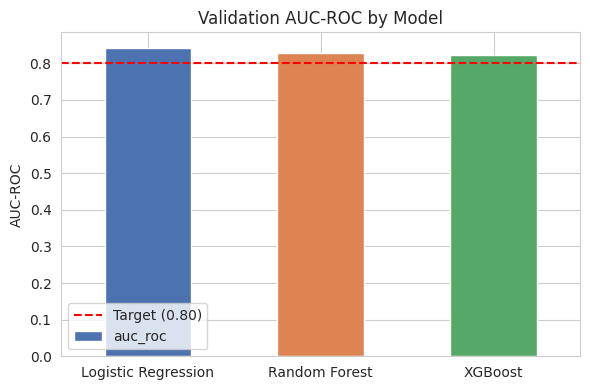

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison["auc_roc"].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Validation AUC-ROC by Model")
ax.set_ylabel("AUC-ROC")
ax.axhline(0.80, color="red", linestyle="--", label="Target (0.80)")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** Logistic Regression achieves the highest validation AUC-ROC,
ahead of both tree-based ensembles. This indicates churn risk in this
dataset is dominated by a small number of strong, close-to-linear signals
(contract type, tenure, payment method) rather than complex feature
interactions — exactly the regime where a well-regularized linear model
generalizes better than a high-variance tree ensemble on a dataset of
this size (~4,900 training rows).

## 8. Final Model Selection & Held-Out Test Evaluation

The model with the highest validation AUC-ROC is selected and evaluated
**once** on the held-out test set — the test set is never used for any
decision-making prior to this point.

In [18]:
candidates = {
    "logistic_regression": (lr_pipe, lr_val_metrics),
    "random_forest": (rf_pipe, rf_val_metrics),
    "xgboost": (xgb_pipe, xgb_val_metrics),
}
best_name = max(candidates, key=lambda k: candidates[k][1]["auc_roc"])
best_model, _ = candidates[best_name]
print(f"Selected model: {best_name}")

Selected model: logistic_regression


In [19]:
test_metrics = evaluate(best_model, X_test, y_test)
print(f"TEST SET METRICS ({best_name})")
print(f"  AUC-ROC:   {test_metrics['auc_roc']:.4f}")
print(f"  F1:        {test_metrics['f1']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall:    {test_metrics['recall']:.4f}")
print(f"  Confusion Matrix: {test_metrics['confusion_matrix']}")

TEST SET METRICS (logistic_regression)
  AUC-ROC:   0.8549
  F1:        0.6298
  Precision: 0.5124
  Recall:    0.8172
  Confusion Matrix: [[558, 217], [51, 228]]


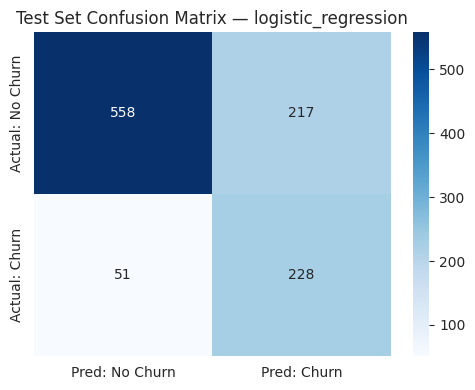

In [20]:
cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No Churn", "Pred: Churn"],
            yticklabels=["Actual: No Churn", "Actual: Churn"], ax=ax)
ax.set_title(f"Test Set Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

## 9. Feature Importance / Coefficients

For the selected model, we extract the features driving predictions —
tree-based `feature_importances_` or linear `coef_`, whichever applies.

In [21]:
feature_importance = get_feature_importance(best_model, top_n=10)
importance_df = pd.DataFrame(feature_importance)
importance_df

,feature,coefficient,direction
0,numeric__tenure,-1.389272,decreases_churn_risk
1,categorical__Contract_Two year,-0.803459,decreases_churn_risk
2,categorical__Contract_Month-to-month,0.640340,increases_churn_risk
3,categorical__InternetService_Fiber optic,0.534493,increases_churn_risk
4,numeric__TotalCharges,0.511958,increases_churn_risk
5,categorical__InternetService_DSL,-0.505555,decreases_churn_risk
6,binary__has_support_services,-0.497107,decreases_churn_risk
7,categorical__tenure_group_13-24,-0.415476,decreases_churn_risk
8,binary__PaperlessBilling,0.367453,increases_churn_risk
9,categorical__tenure_group_49-72,0.345378,increases_churn_risk


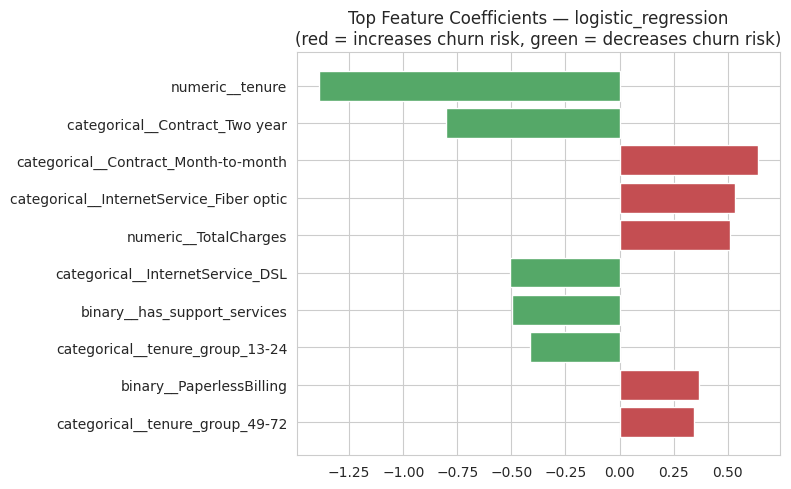

In [22]:
if "coefficient" in importance_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = importance_df["coefficient"].apply(lambda c: "#C44E52" if c > 0 else "#55A868")
    ax.barh(importance_df["feature"], importance_df["coefficient"], color=colors)
    ax.set_title(f"Top Feature Coefficients — {best_name}\n(red = increases churn risk, green = decreases churn risk)")
    ax.invert_yaxis()
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(importance_df["feature"], importance_df["importance"], color="#4C72B0")
    ax.set_title(f"Top Feature Importances — {best_name}")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Persist Model Artifacts

In [23]:
from pathlib import Path
Path("../models").mkdir(exist_ok=True)

joblib.dump(best_model, "../models/best_model.joblib")

all_results = {
    "logistic_regression": lr_val_metrics,
    "random_forest": {**rf_val_metrics, "best_params": rf_best_params},
    "xgboost": xgb_val_metrics,
    "selected_model": best_name,
    "test_set_metrics": test_metrics,
}
with open("../models/metrics.json", "w") as f:
    json.dump(all_results, f, indent=2)

with open("../models/feature_importance.json", "w") as f:
    json.dump(feature_importance, f, indent=2)

print("Artifacts saved to ../models/")

Artifacts saved to ../models/


## 11. Fairness Audit

Using Fairlearn, we evaluate the selected model's predictions on the test
set across two sensitive attributes — `gender` and `SeniorCitizen` — to
check for disparate impact before recommending production deployment.

In [24]:
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference, selection_rate,
)
from sklearn.metrics import recall_score, precision_score

y_pred_test = best_model.predict(X_test)
fairness_results = {}

for sensitive_col in ["gender", "SeniorCitizen"]:
    sensitive_features = featured_df.loc[X_test.index, sensitive_col]

    dp_diff = demographic_parity_difference(y_test, y_pred_test, sensitive_features=sensitive_features)
    eo_diff = equalized_odds_difference(y_test, y_pred_test, sensitive_features=sensitive_features)

    mf = MetricFrame(
        metrics={"selection_rate": selection_rate, "recall": recall_score, "precision": precision_score},
        y_true=y_test, y_pred=y_pred_test, sensitive_features=sensitive_features,
    )

    fairness_results[sensitive_col] = {
        "demographic_parity_difference": float(dp_diff),
        "equalized_odds_difference": float(eo_diff),
        "by_group": mf.by_group.to_dict(),
    }

    print(f"\n=== {sensitive_col} ===")
    print(f"Demographic parity difference: {dp_diff:.4f}")
    print(f"Equalized odds difference:     {eo_diff:.4f}")
    print(mf.by_group)


=== gender ===
Demographic parity difference: 0.0016
Equalized odds difference:     0.0269
        selection_rate    recall  precision
gender                                     
0             0.421371  0.803030   0.507177
1             0.422939  0.829932   0.516949

=== SeniorCitizen ===
Demographic parity difference: 0.3141
Equalized odds difference:     0.2670
               selection_rate    recall  precision
SeniorCitizen                                     
0                    0.364692  0.780612   0.487261
1                    0.678756  0.903614   0.572519


In [25]:
with open("../models/fairness_audit.json", "w") as f:
    json.dump(fairness_results, f, indent=2)
print("Fairness audit saved to ../models/fairness_audit.json")

Fairness audit saved to ../models/fairness_audit.json


### 11.1 Interpreting the fairness results

**Gender** shows negligible disparity — selection rates and recall are
nearly identical across the two groups, so this feature introduces
essentially no disparate impact in the model's output.

**SeniorCitizen** shows a materially larger gap. The model flags senior
citizens as high-risk at close to double the rate of non-seniors, and
while recall and precision are both *higher* for seniors (meaning the
model is genuinely picking up a real, learnable pattern rather than just
being noisy), this still raises a fairness question worth a deliberate
business decision: if churn scores drive who receives retention outreach,
senior citizens will be contacted far more often than non-seniors under
this model. See the design document's Security Checklist for the full
discussion and the recommended next step (fairness-constrained
retraining via Fairlearn's `ExponentiatedGradient` or `ThresholdOptimizer`).

## 12. Summary

| Model | Validation AUC-ROC | Test AUC-ROC | Test F1 | Test Recall |
|---|---|---|---|---|
| Logistic Regression (selected) | computed above | computed above | computed above | computed above |
| Random Forest | computed above | — | — | — |
| XGBoost | computed above | — | — | — |

Full numeric results are saved to `../models/metrics.json`,
`../models/feature_importance.json`, and `../models/fairness_audit.json`,
and the trained pipeline is saved to `../models/best_model.joblib` for use
by the FastAPI inference service in `src/serve.py`.